In [24]:
!pip install kagglehub

In [25]:
from google.colab import files
files.upload()

Saving archive (1).zip to archive (1) (1).zip


In [26]:
!unzip "archive (1).zip"

Archive:  archive (1).zip
replace Dataset_BUSI_with_GT/benign/benign (1).png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [27]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [28]:
dataset_path = "Dataset_BUSI_with_GT"

In [29]:
data = []
labels = []

classes = ["normal","benign","malignant"]

for label, category in enumerate(classes):

    path = os.path.join(dataset_path,category)

    for img in os.listdir(path):

        if "mask" in img:
            continue

        img_path = os.path.join(path,img)

        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image,(128,128))

        data.append(image)
        labels.append(label)

In [30]:
data = np.array(data)
labels = np.array(labels)

print(data.shape)

(780, 128, 128, 3)


In [31]:
X_train,X_test,y_train,y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

In [32]:
y_train = to_categorical(y_train,3)
y_test = to_categorical(y_test,3)

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

In [42]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

In [50]:
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(3,activation='softmax'))

In [51]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test,y_test)
)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 606ms/step - accuracy: 0.5272 - loss: 2.9861 - val_accuracy: 0.5256 - val_loss: 1.0502
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 643ms/step - accuracy: 0.5641 - loss: 0.9175 - val_accuracy: 0.5385 - val_loss: 1.1330
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 39s 598ms/step - accuracy: 0.5978 - loss: 0.8355 - val_accuracy: 0.6346 - val_loss: 0.9373
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 42s 608ms/step - accuracy: 0.6731 - loss: 0.7631 - val_accuracy: 0.6603 - val_loss: 1.0533
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 40s 593ms/step - accuracy: 0.6939 - loss: 0.7341 - val_accuracy: 0.6282 - val_loss: 0.9515
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 562ms/step - accuracy: 0.7436 - loss: 0.6243 - val_accuracy: 0.6859 - val_loss: 0.7924
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 594ms/step - accuracy: 0.7917 - loss: 0.5522 - val_accuracy: 0.7244 - val_loss: 0.8165
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 41s 592ms/step - accuracy: 0.7949 - loss: 0.4802 - val_accu

In [53]:
loss,accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - accuracy: 0.7821 - loss: 1.4620
Test Accuracy: 0.7820512652397156


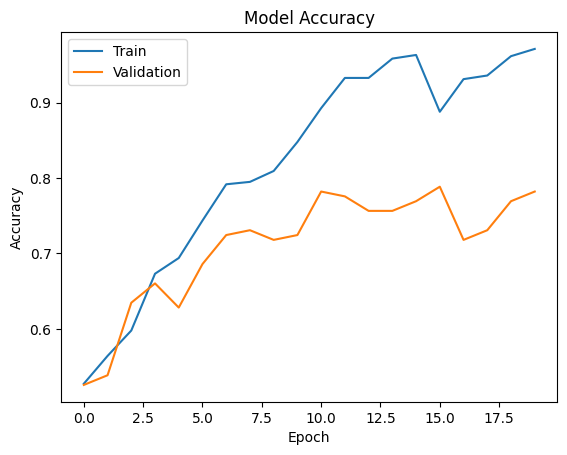

In [54]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step


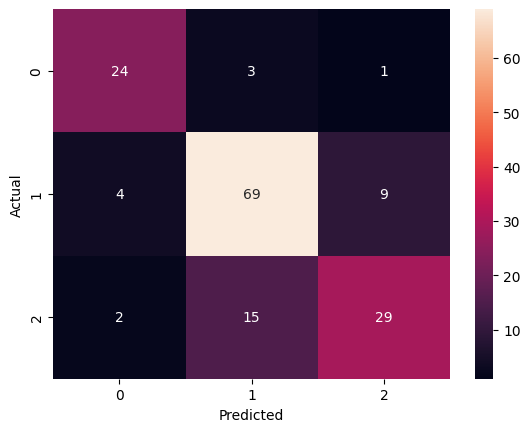

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

pred = model.predict(X_test)
pred = np.argmax(pred,axis=1)
true = np.argmax(y_test,axis=1)

cm = confusion_matrix(true,pred)

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()